In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [22]:
def plot_auroc_by_task(
    df: pd.DataFrame,
    task_col: str = "Task",
    model_col: str = "Model",
    auroc_col: str = "AU-ROC",
    task_order=None,
    model_order=None,
    # title: str = "AUROC by Task",
    # subtitle: str | None = "Higher is better",
    # ylim=(0.5, 1.0),
    annotate: bool = True,
    legend_ncol: int = 2,
    out_png: str | None = "auroc_by_task.png",
    out_pdf: str | None = "auroc_by_task.pdf",
):
    """
    df must be 'long' format: one row per (task, model), with AUROC in [0,1].
    Example columns: task, model, auroc
    """

    d = df.copy()

    # Validate
    for c in [task_col, model_col, auroc_col]:
        if c not in d.columns:
            raise ValueError(f"Missing required column: {c}")
    if d[auroc_col].isna().any():
        raise ValueError("AUROC column contains NaNs; fill or drop them before plotting.")

    # Orders
    if task_order is None:
        task_order = list(pd.unique(d[task_col]))
    if model_order is None:
        model_order = list(pd.unique(d[model_col]))

    d[task_col] = pd.Categorical(d[task_col], categories=task_order, ordered=True)
    d[model_col] = pd.Categorical(d[model_col], categories=model_order, ordered=True)
    d = d.sort_values([task_col, model_col])

    # Pivot for plotting
    M = (
        d.pivot_table(index=task_col, columns=model_col, values=auroc_col, aggfunc="mean")
        .reindex(index=task_order, columns=model_order)
    )

    # --- Style tuned for slides ---
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 22,
        "axes.titlesize": 30,
        "axes.labelsize": 26,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 22,
        "figure.dpi": 300,
        "savefig.dpi": 300,
    })
    
    palette = {
        "Learned embeddings": "#8da0cb", # "#4E79A7",  # muted blue
        "GNN":            "#fc8d62", # "#F28E2B",  # muted orange
        "EVO":            "#66c2a5", # "#59A14F",  # muted green
        "QWEN":           "#e78ac3" # "#B07AA1",  # muted purple
    }

    n_tasks = len(task_order)
    n_models = len(model_order)

    # Figure size: wide but not too tall (good for PPT)
    fig_w = max(17, 2 * n_tasks)
    fig_h = 8.0
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    x = np.arange(n_tasks)
    group_width = 0.78
    bar_w = group_width / n_models

    # Use matplotlib default color cycle (professional, consistent)
    colors = [f"C{i}" for i in range(n_models)]

    for i, model in enumerate(model_order):
        y = M[model].to_numpy()
        offsets = x - group_width/2 + (i + 0.5) * bar_w
        bars = ax.bar(offsets, y, width=bar_w * 0.95, label=str(model), color=palette[str(model)]) #=colors[i])

        if annotate:
            for b, val in zip(bars, y):
                if np.isnan(val):
                    continue
                ax.text(
                    b.get_x() + b.get_width()/2,
                    val + 0.006,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=11,
                )

    # Axes + grid
    # ax.set_title(title, pad=16)
    # if subtitle:
    #     ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=12.5)

    ax.set_xticks(x)
    ax.set_xticklabels(task_order, rotation=0)
    ax.set_ylabel("AU-ROC")
    # ax.set_ylim(*ylim)

    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.grid(True, linestyle="-", linewidth=0.8, alpha=0.15)
    ax.xaxis.grid(False)

    # Minimal spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.1, 1.1),  # <-- increase 1.03 -> 1.06 to move right
        frameon=True,
    )
    # ax.legend(loc="upper right", frameon=False)
    # ax.legend(
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 1.16),
    #     ncol=min(legend_ncol, n_models),
    #     frameon=False,
    #     handlelength=1.8,
    #     columnspacing=1.2,
    # )

    fig.tight_layout(pad=1.5)

    if out_png:
        fig.savefig(out_png, bbox_inches="tight", transparent=False)
    if out_pdf:
        fig.savefig(out_pdf, bbox_inches="tight", transparent=True)

    return fig, ax

In [3]:
res = pd.read_csv('init_res.csv')
res

,Task,Learned embeddings,GNN,EVO,QWEN
0,Location,94.8,90.5,92.4,93.6
1,Sex,54.7,54.5,56.0,57.0
2,Supplement,64.0,55.4,72.4,59.2
3,H. Pylori infection,93.1,91.8,92.4,91.9
4,HBV infection,65.7,47.3,67.0,39.2


In [4]:
df_long = res.melt(id_vars="Task", var_name="Model", value_name="AU-ROC")
if df_long["AU-ROC"].max() > 1.5:
    df_long["AU-ROC"] = df_long["AU-ROC"] / 100.0
df_long

,Task,Model,AU-ROC
0,Location,Learned embeddings,0.948
1,Sex,Learned embeddings,0.547
2,Supplement,Learned embeddings,0.640
3,H. Pylori infection,Learned embeddings,0.931
4,HBV infection,Learned embeddings,0.657
5,Location,GNN,0.905
6,Sex,GNN,0.545
7,Supplement,GNN,0.554
8,H. Pylori infection,GNN,0.918
9,HBV infection,GNN,0.473


/tmp/ipykernel_3436313/132065390.py:42: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d.pivot_table(index=task_col, columns=model_col, values=auroc_col, aggfunc="mean")


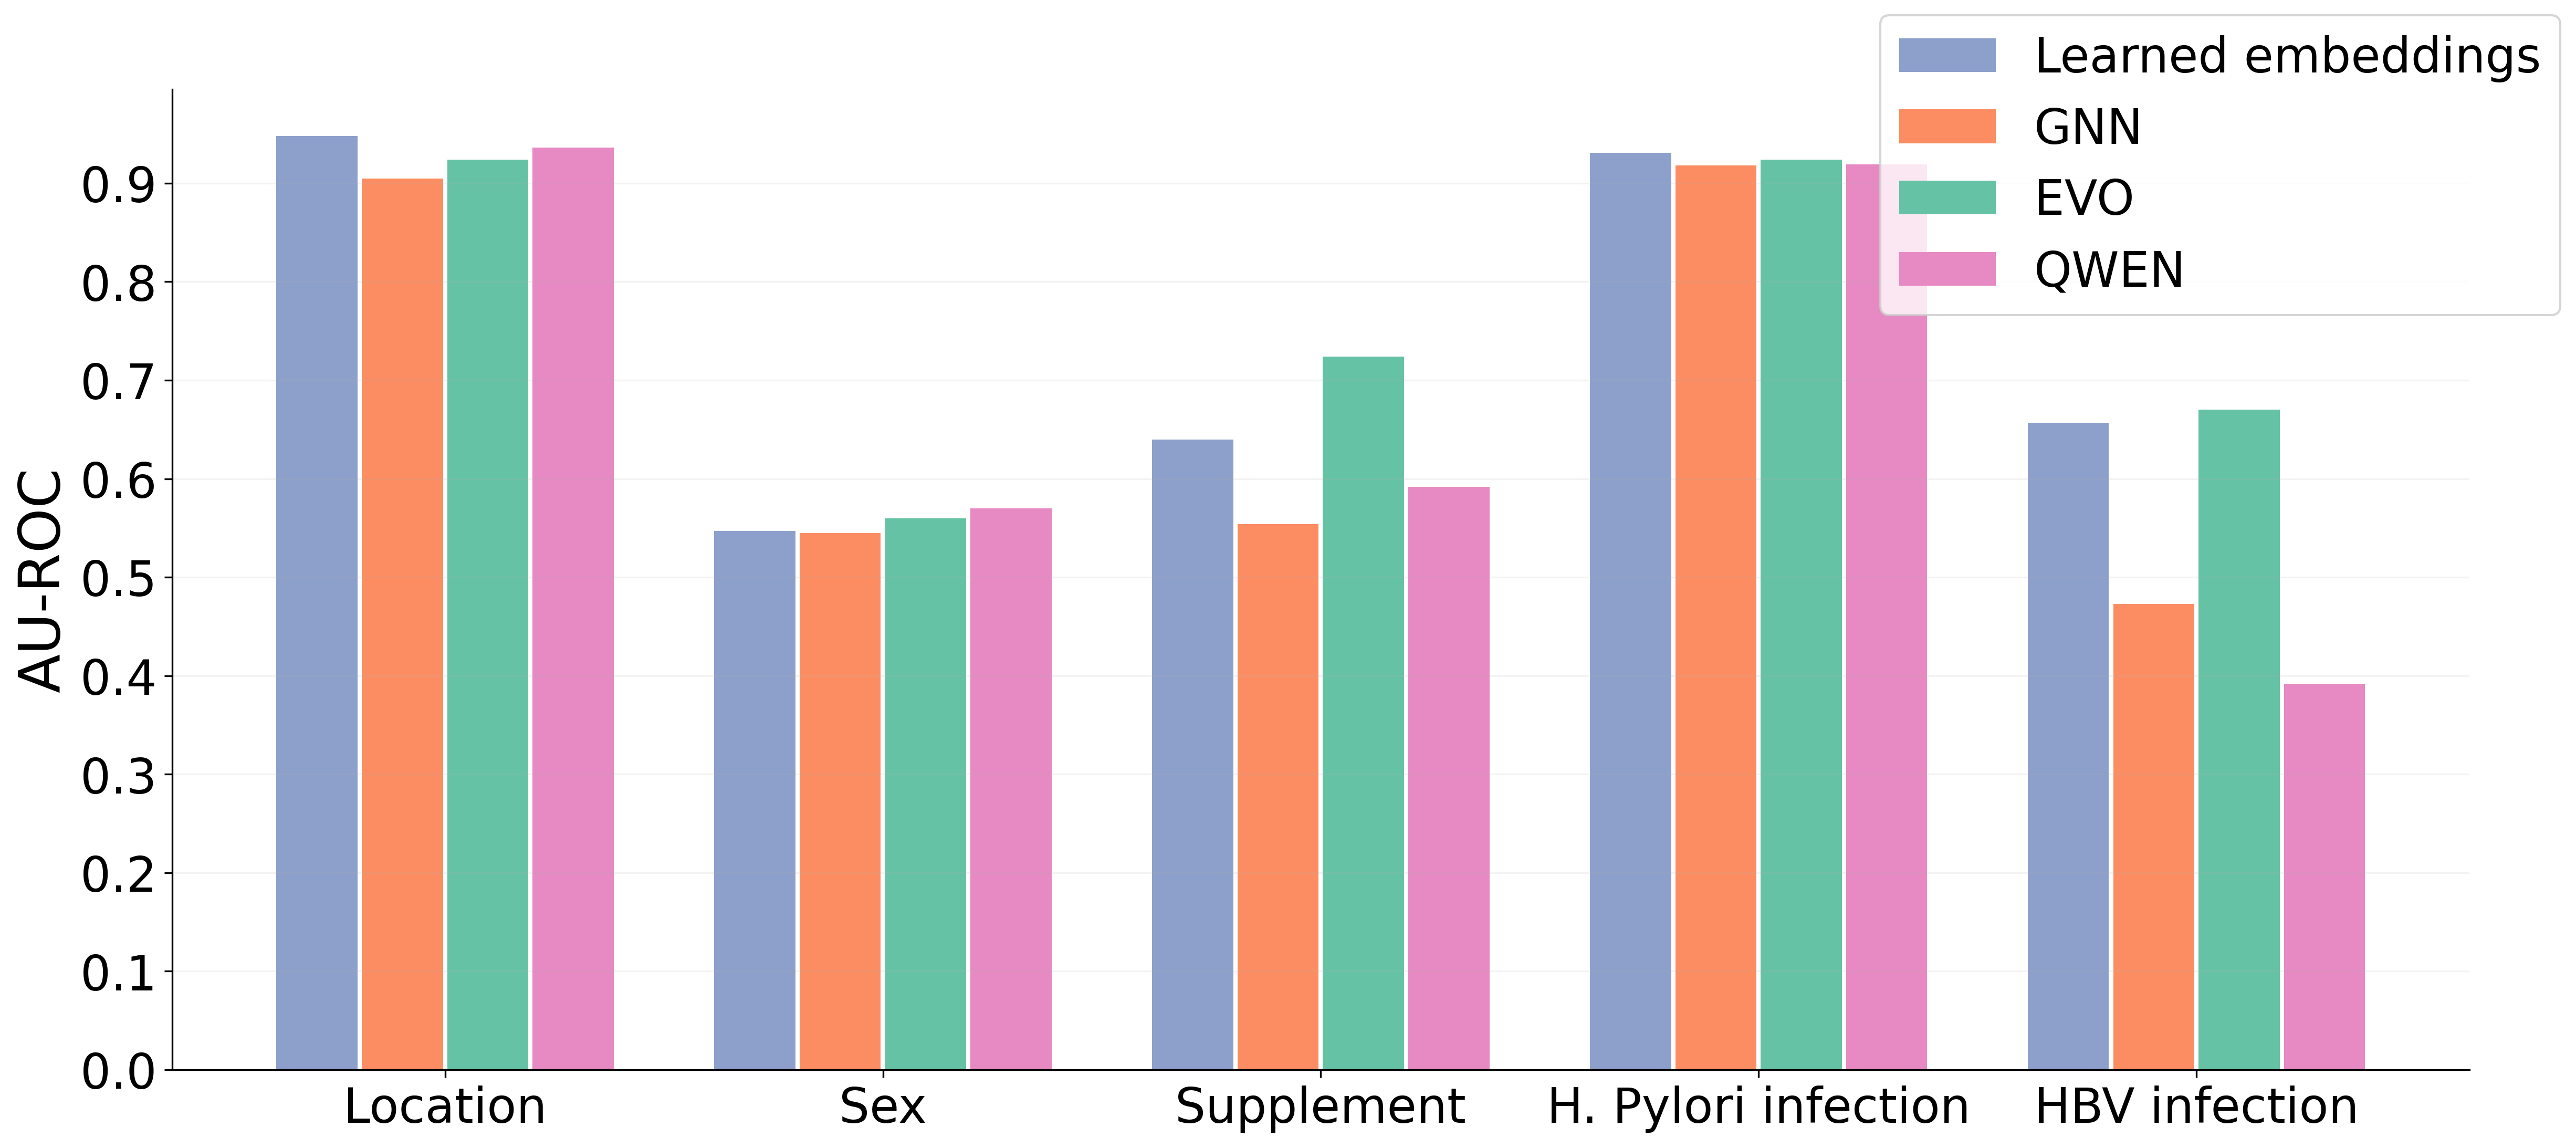

In [23]:
plot_auroc_by_task(df_long, out_png="auroc_by_task.png",annotate=False)
plt.show()

In [1]:
## Explore embeddings

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import anndata as ad
import umap
from sklearn.decomposition import PCA



from matplotlib import pyplot as plt
from skbio.stats.composition import closure, clr

/home/dpellow/hmbenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
def plot_umap(data, proj_ids, depths):
    reducer = umap.UMAP(n_components=2,min_dist = 0.2,metric='cosine')
    data_umap = reducer.fit_transform(data)
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    sns.scatterplot(x=data_umap[:,0], y=data_umap[:,1], hue = proj_ids, alpha=0.5,legend = False, ax=axs[0])
    sns.scatterplot(x=data_umap[:,0], y=data_umap[:,1], hue = depths, alpha=0.5,legend = False, ax=axs[1])


In [23]:
data_path = "/project/aip-rahulgk/gutmodel/hmc_final_fixed/downstream_train.h5ad"
data = ad.read_h5ad(data_path)
data = data[data.obs['downstream_task']=='bmi']

print(data)
proj_ids = data.obs['study_id'].apply(lambda x: x.split('_')[0]).values
depths = data.X.sum(axis=1)
# data processing
counts_pc = data.X+1e-8
closure_data = closure(counts_pc)
clr_data = clr(closure_data)
log_data = np.log(closure_data)  

View of AnnData object with n_obs × n_vars = 2866 × 1514
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'


/home/dpellow/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


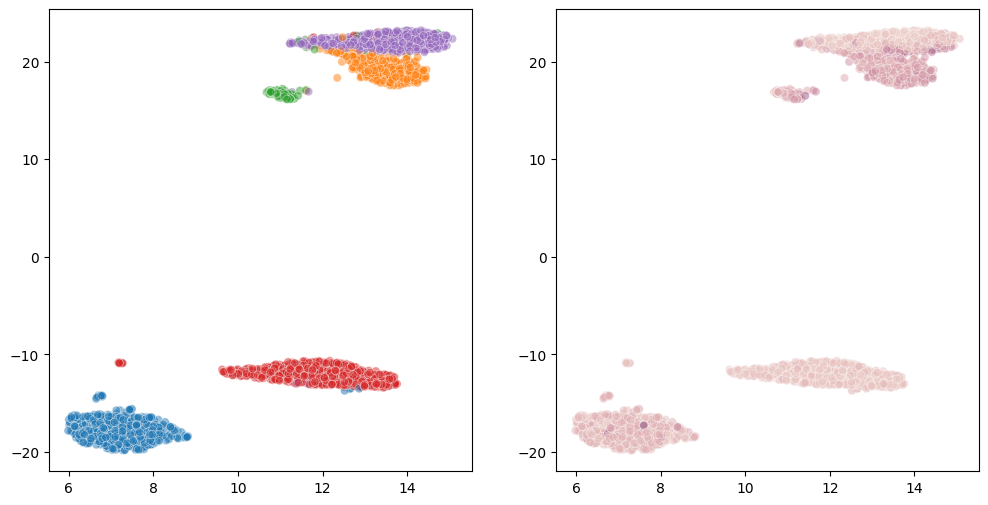

In [18]:
# raw data
plot_umap(clr_data,proj_ids,depths)

/home/dpellow/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 2866 × 128
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'


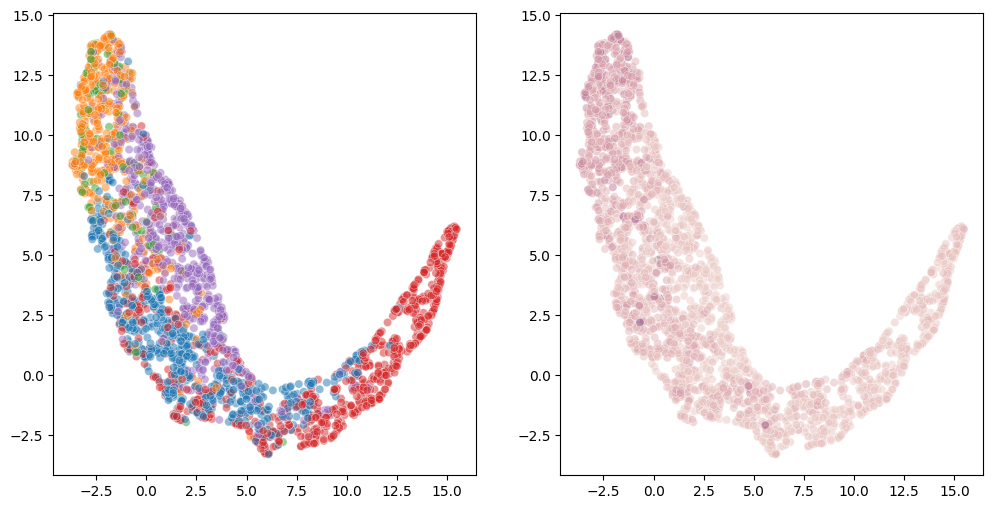

In [33]:
# unmasking
data_path = "/home/dpellow/projects/aip-rahulgk/dpellow/gut_microbiome_GPT/outputs/eval/final/masking_clr_len200_7layers_ratio_70_updated_pool/downstream_train.h5ad"
data = ad.read_h5ad(data_path)
data = data[data.obs['downstream_task']=='bmi']

print(data)
proj_ids = data.obs['study_id'].apply(lambda x: x.split('_')[0]).values
# depths = data.X.sum(axis=1)
plot_umap(data.X,proj_ids,depths)

/home/dpellow/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 2866 × 128
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'


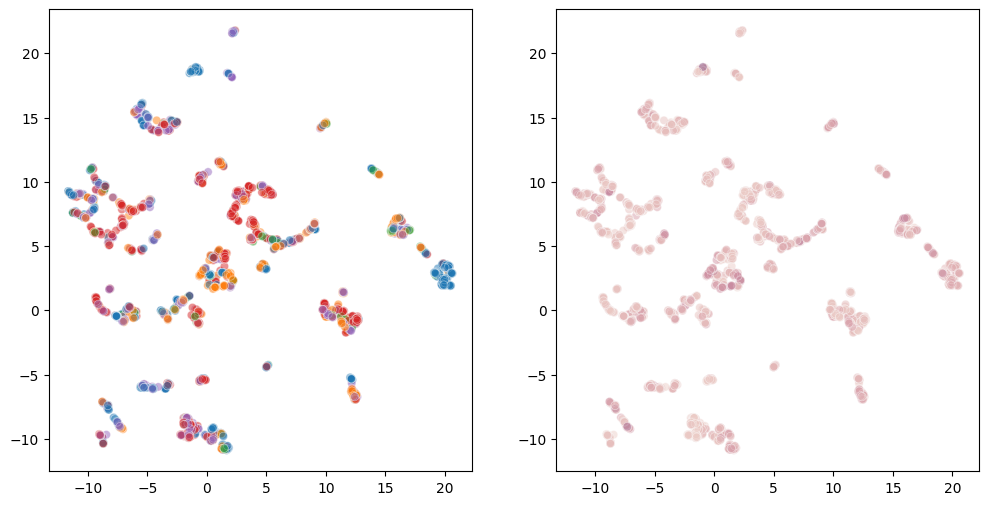

In [34]:
# contrastive
data_path = "/home/dpellow/projects/aip-rahulgk/dpellow/gut_microbiome_GPT/outputs/eval/contrastive/log_rel_ab_3layers_multinomial_1_70_cls_emb_cls/downstream_train.h5ad"
data = ad.read_h5ad(data_path)
data = data[data.obs['downstream_task']=='bmi']

print(data)
proj_ids = data.obs['study_id'].apply(lambda x: x.split('_')[0]).values
# depths = data.X.sum(axis=1)
plot_umap(data.X,proj_ids,depths)

/home/dpellow/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 2866 × 128
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'


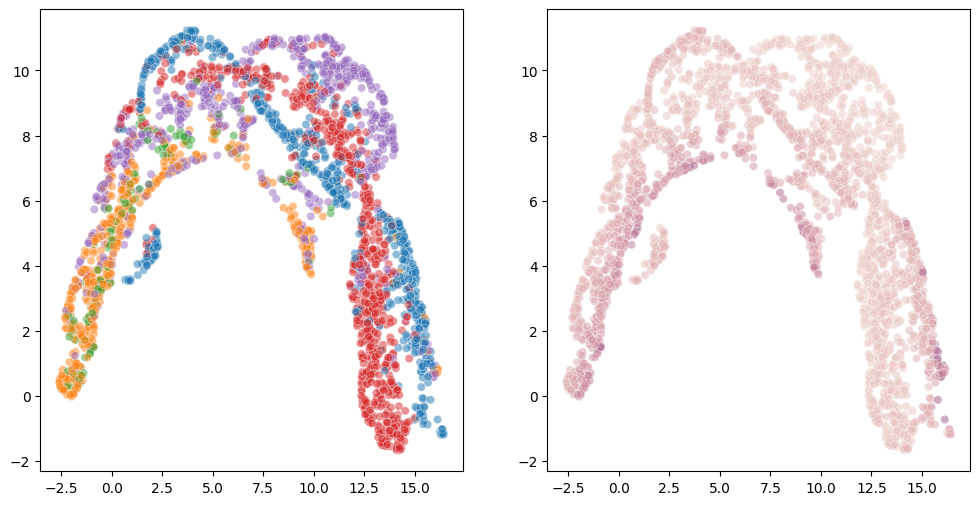

In [35]:
# denoising
data_path = "/home/dpellow/projects/aip-rahulgk/dpellow/gut_microbiome_GPT/outputs/eval/denoising/counts_3layers_multinomial_1_70_cls/downstream_train.h5ad"
data = ad.read_h5ad(data_path)
data = data[data.obs['downstream_task']=='bmi']

print(data)
proj_ids = data.obs['study_id'].apply(lambda x: x.split('_')[0]).values
# depths = data.X.sum(axis=1)
plot_umap(data.X,proj_ids,depths)

/home/dpellow/hmbenv/lib/python3.11/site-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


View of AnnData object with n_obs × n_vars = 2866 × 128
    obs: 'drr', 'study_id', 'region', 'total_bases', 'instrument', 'downstream_task', 'categorical_label', 'continuous_label'


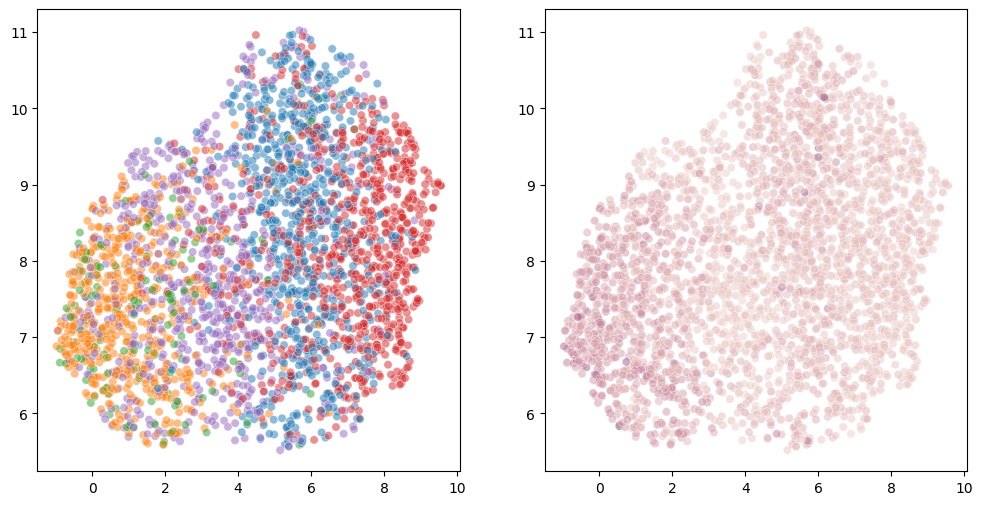

In [36]:
# denoising_contrastive
data_path = "/home/dpellow/projects/aip-rahulgk/dpellow/gut_microbiome_GPT/outputs/eval/denoising_contrastive/counts_7layers_wd_200_20_80_cls_pool/downstream_train.h5ad"
data = ad.read_h5ad(data_path)
data = data[data.obs['downstream_task']=='bmi']

print(data)
proj_ids = data.obs['study_id'].apply(lambda x: x.split('_')[0]).values
# depths = data.X.sum(axis=1)
plot_umap(data.X,proj_ids,depths)